In [85]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt
import typing
import torch
import random

from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision.transforms import v2
from skimage.filters import sobel
from utils.mask_utils import remap_labels

In [92]:
DATA_PATH = os.getcwd() + "/DATA/"
SPLIT = "train/"
PRE_EVENT_PATH = f"{DATA_PATH}{SPLIT}pre-event"
POST_EVENT_PATH = f"{DATA_PATH}{SPLIT}post-event"
TARGET_PATH = f"{DATA_PATH}{SPLIT}target"
INDEX_PATH = f"{DATA_PATH}index/patch_metadata.npz"


## Hyperparameter
VALID_THR = 0.25
CHANGE_THR = 0.001
HARD_NEG_THR = 0.10
INFORMATIVE_THR = 0.0840

In [93]:
class ChangeDetctionDataset(Dataset):
    def __init__(self,
                 pre_img_path: str,
                 post_img_path: str,
                 target_img_path: str,
                 patch_size: int,
                 stride: int,
                 index_path: typing.Optional[str], 
                 build_metadata: bool = True,
                 transform: typing.Optional[str] = None):
        
        self.pre_img_path = pre_img_path
        self.post_img_path = post_img_path
        self.target_img_path = target_img_path
        self.patch_size = patch_size
        self.stride = stride
        self.height = 1024
        self.width = 1024

        self.pre_files = sorted(os.listdir(self.pre_img_path))
        self.post_files = sorted(os.listdir(self.post_img_path))
        self.target_files = sorted(os.listdir(self.target_img_path))

        self.coords = self._generate_patch_coordinates()
        self.build_metadata = build_metadata
        self.transform = transform
        if self.build_metadata:
            if index_path and os.path.exists(index_path):
                self.patch_metadata = self._load_patch_metadata(index_path)
            else:
                self.patch_metadata, self.temp1, self.temp2 = self._build_patch_metadata()
                if index_path:
                    # os.makedirs(os.path.dirname(index_path), exist_ok=True)
                    np.savez(index_path, metadata=np.array(self.patch_metadata, dtype=object))
        else:
            self.patch_metadata = None
            self.total_patches = len(self.pre_files) * len(self.coords)
    
    def _generate_patch_coordinates(self):
        coords = []
        for y in range(0, self.height - self.patch_size + 1, self.stride):
            for x in range(0, self.width - self.patch_size + 1, self.stride):
                coords.append((x, y))
        return coords

    def _integral_image(self, arr: np.ndarray) -> np.ndarray:
        return arr.cumsum(axis=0).cumsum(axis=1)

    def _window_sum(self, ii: np.ndarray, x: int, y: int, h: int, w: int) -> float:
        x2 = x + w - 1
        y2 = y + h - 1
        total = ii[y2, x2]
        if y > 0:
            total -= ii[y - 1, x2]
        if x > 0:
            total -= ii[y2, x - 1]
        if x > 0 and y > 0:
            total += ii[y - 1, x - 1]
        return float(total)

    def _normalize01(self, img: np.ndarray) -> np.ndarray:
        img = img.astype(np.float16)
        min_val = float(img.min())
        max_val = float(img.max())
        return (img - min_val) / (max_val - min_val + 1e-6)

    def _read_patch(self, folder_path, filename, x, y):
        file_path = os.path.join(folder_path, filename)
        with rasterio.open(file_path) as src:
            window = rasterio.windows.Window(x, y, self.patch_size, self.patch_size)
            data = src.read(window=window)
            if src.nodata is not None:
                data = np.where(data == src.nodata, 0, data)
            data = np.nan_to_num(data, nan=0.0)

        data = np.transpose(data, (1, 2, 0)).astype(np.float16)
        return data
    
    def _load_patch_metadata(self, index_path: str):
        data = np.load(index_path, allow_pickle=True)
        return data["metadata"].tolist()     
    
    def _build_patch_metadata(self):
        metadata = []
        score_list = []
        change_list = []

        for image_idx in range(len(self.pre_files)):
            with rasterio.open(os.path.join(self.pre_img_path, self.pre_files[image_idx])) as src1, rasterio.open(os.path.join(self.post_img_path, self.post_files[image_idx])) as src2, rasterio.open(os.path.join(self.target_img_path, self.target_files[image_idx])) as target:
                pre_full = src1.read(masked=True)
                target_full = target.read(masked=True)
                post_full = src2.read(masked=True)

                pre_img = np.ma.filled(pre_full, 0.0)
                post_img = np.ma.filled(post_full, 0.0)

                if pre_img.ndim == 3:
                    pre2d = pre_img.mean(axis=0) if pre_img.shape[0] > 1 else pre_img[0]
                else:
                    pre2d = pre_img

                if post_img.ndim == 3:
                    post2d = post_img.mean(axis=0) if post_img.shape[0] > 1 else post_img[0]
                else:
                    post2d = post_img

                pre2d = self._normalize01(pre2d)
                post2d = self._normalize01(post2d)

                grad_map = sobel(post2d).astype(np.float32)
                grad_ii = self._integral_image(grad_map)

                for idx, (x, y) in enumerate(self.coords):
                    pre = pre_full[:, y:y+self.patch_size, x:x+self.patch_size]
                    valid_mask = ~np.ma.getmaskarray(pre)
                    valid_mask = np.any(valid_mask, axis=0)

                    post_patch = post_img[:, y:y+self.patch_size, x:x+self.patch_size]
                    post_valid_mask = np.any(post_patch != 0, axis=0)

                    combined_valid = valid_mask & post_valid_mask
                    valid_ratio = combined_valid.mean()

                    if valid_ratio < VALID_THR:
                        metadata.append({
                            "image_idx": image_idx,
                            "patch_idx": idx,
                            "x": x,
                            "y": y,
                            "bucket": "discard",
                        })
                        continue

                    label = target_full[:, y:y+self.patch_size, x:x+self.patch_size]
                    label = label.astype(np.uint8)
                    label = np.nan_to_num(label, 0)
                    label = np.transpose(label, (1, 2, 0))
                    label = label.squeeze()
                    binary_mask = remap_labels(label).astype(np.uint8)
                    changed_pixel = binary_mask.sum()
                    changed_ratio = (changed_pixel/max(1, combined_valid.sum()))

                    score = self._window_sum(grad_ii, x, y, self.patch_size, self.patch_size) / (self.patch_size * self.patch_size)
                    score_list.append(score)
                    change_list.append(changed_ratio)

                    if changed_ratio <= CHANGE_THR:
                        if score >= HARD_NEG_THR:
                            metadata.append({
                                "image_idx": image_idx,
                                "patch_idx": idx,
                                "x": x,
                                "y": y,
                                "bucket": "hard_negative",
                            })
                        else:
                            metadata.append({
                                "image_idx": image_idx,
                                "patch_idx": idx,
                                "x": x,
                                "y": y,
                                "bucket": "trivial",
                            })
                    elif score >= INFORMATIVE_THR:
                        metadata.append({
                            "image_idx": image_idx,
                            "patch_idx": idx,
                            "x": x,
                            "y": y,
                            "bucket": "informative",
                        })
                    else:
                        metadata.append({
                            "image_idx": image_idx,
                            "patch_idx": idx,
                            "x": x,
                            "y": y,
                            "bucket": "trivial",
                        })

        return metadata, score_list, change_list
                        
         
    def __len__(self):
        if self.patch_metadata is not None:
            return len(self.patch_metadata)
        return self.total_patches
    
    def __getitem__(self, idx):
        if self.build_metadata:
            image_idx = int(self.patch_metadata[idx]["image_idx"])
            patch_idx = int(self.patch_metadata[idx]["patch_idx"])
            x = self.patch_metadata[idx]["x"]
            y = self.patch_metadata[idx]["y"]
            meta = self.patch_metadata[idx]
        else:
            coord_count = len(self.coords)
            image_idx = idx // coord_count
            coord_idx = idx % coord_count
            x, y = self.coords[coord_idx]
            meta = {"image_idx": image_idx, "patch_idx": coord_idx, "x": x, "y": y}

        pre = self._read_patch(self.pre_img_path, self.pre_files[image_idx], x, y)
        post = self._read_patch(self.post_img_path, self.post_files[image_idx], x, y)
        target = self._read_patch(self.target_img_path, self.target_files[image_idx], x, y)

        target = remap_labels(target)
        if self.transform:
            transformed = self.transform(
                image1=pre,
                image2=post,
                mask=target,
            )
            pre = transformed["image1"]
            post = transformed["image2"]
            target = transformed["mask"]
        
        return pre, post, target, meta

In [94]:
class PairedTransform:
    def __init__(self,horizontal_flip_p=0.5, vertical_flip_p=0.5):
        # normalize: callable that expects (image1, image2) -> (image1, image2)
        # augment: callable that expects (image1, image2, mask) -> (image1, image2, mask)
        # to_tensor: callable that expects (image1, image2, mask) -> (image1, image2, mask)
        self.horizontal_flip_p = horizontal_flip_p
        self.vertical_flip_p = vertical_flip_p
        self.optical_augment = v2.RandomApply(
            [
                v2.ColorJitter(
                    brightness=0.15,
                    contrast=0.15,
                    saturation=0.10,
                    hue=0.02,
                ),
            ], p=0.5)
        self.sar_augment = v2.RandomApply(
            [
                v2.Lambda(lambda x: x *torch.empty(1).uniform_(0.98,1.02)),
            ], p=0.5)
        
        self.blur = v2.RandomApply(
            [
                v2.GaussianBlur(kernel_size=3)
            ], p=0.1)

    def __call__(self, image1, image2, mask):

        image2 = self._sar_normalization(image2)
        image1 = self._optical_normalization(image1)

        image1 = torch.from_numpy(image1).float().permute(2, 0, 1)
        image2 = torch.from_numpy(image2).float().permute(2, 0, 1)
        mask = torch.from_numpy(mask.squeeze()).long()

        image1 = self.optical_augment(image1)
        image2 = self.sar_augment(image2)

        image1 = self.blur(image1)
        image2 = self.blur(image2)

        image1, image2, mask = self._paired_augment(image1, image2, mask)


        return {"image1": image1, "image2": image2, "mask": mask}

    def _sar_normalization(self, image2):
        p2, p98 = np.percentile(image2, (2, 98))
        image2 = np.clip(image2, p2, p98)
        image2 = (image2 - image2.min())/(image2.max() - image2.min() + 1e-6)
        return image2
        
    def _optical_normalization(self, image1):
        p2, p98 = np.percentile(image1, (2, 98))
        image1 = np.clip(image1, p2, p98)
        image1 = (image1 - image1.min())/(image1.max() - image1.min() + 1e-6)
        return image1
    
    def _paired_augment(self, image1, image2, mask):
        if random.random() < self.horizontal_flip_p:
            image1 = v2.functional.hflip(image1)
            image2 = v2.functional.hflip(image2)
            mask = v2.functional.hflip(mask)

        if random.random() < self.vertical_flip_p:
            image1 = v2.functional.vflip(image1)
            image2 = v2.functional.vflip(image2)
            mask = v2.functional.vflip(mask)
        
        return image1, image2, mask


dataset = ChangeDetctionDataset(
    PRE_EVENT_PATH,
    POST_EVENT_PATH,
    TARGET_PATH,
    patch_size=256,
    stride=128,
    index_path=INDEX_PATH,
    build_metadata=True,
    transform=PairedTransform(horizontal_flip_p=0.50, vertical_flip_p=0.50)
)

In [95]:
class BucketBatchSampler(Sampler):
    def __init__(self, metadata, batch_size, ratio):
        self.batch_size = batch_size
        self.buckets = {
            k: [i for i, m in enumerate(metadata) if m["bucket"] == k]
            for k in ratio
        }
        self.ratio = ratio

    def __iter__(self):
        while True:
            batch = []
            for k, r in self.ratio.items():
                k_count = int(self.batch_size * r)
                batch += random.sample(self.buckets[k], k_count)
            random.shuffle(batch)
            yield batch

batch_sampler = BucketBatchSampler(
    dataset.patch_metadata,
    batch_size = 8,
    ratio={
        "informative": 0.625,
        "hard_negative": 0.25,
        "trivial":0.125
    }
)


train_loader = DataLoader(
    dataset,
    batch_sampler=batch_sampler
)

torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 256]) torch.Size([8, 256, 256]) 5


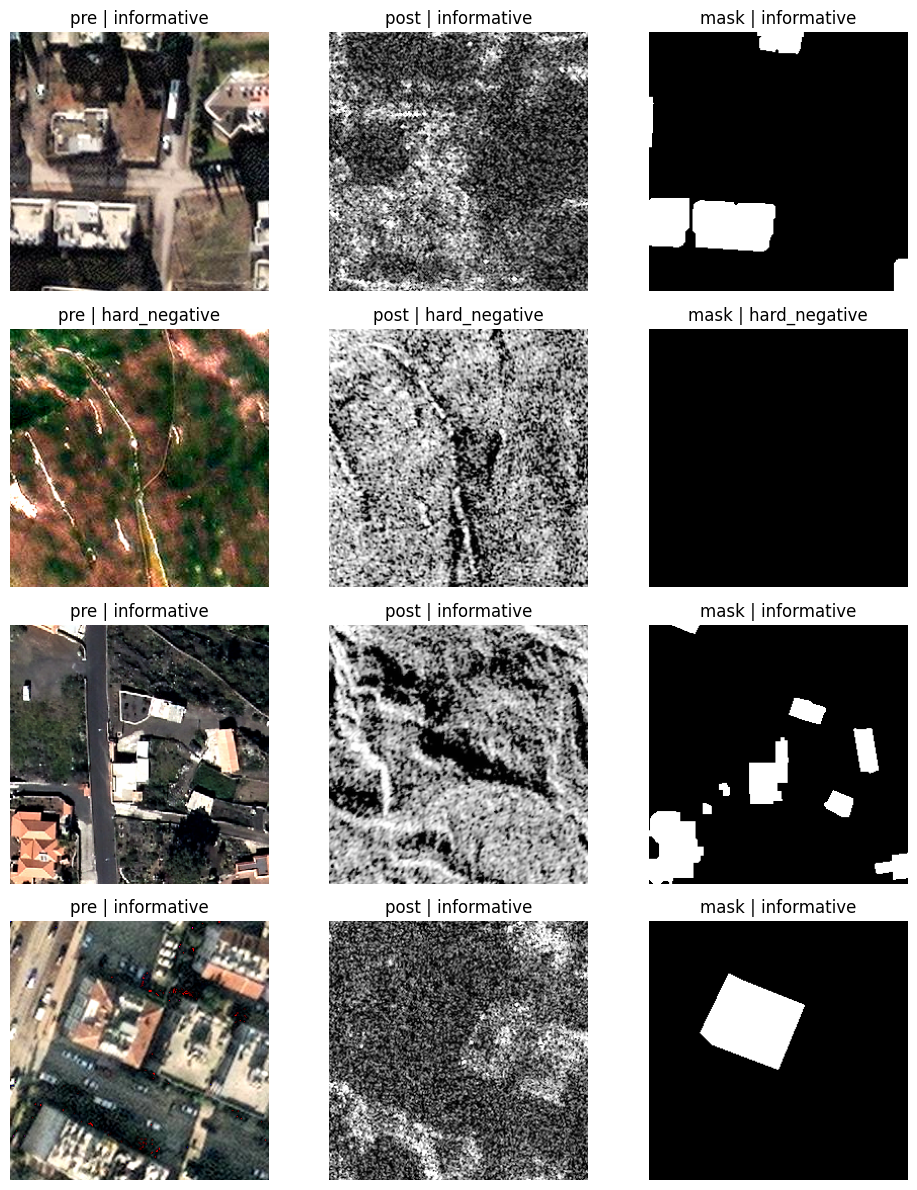

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def _to_rgb(img):
    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()
    if img.ndim == 3:
        img = np.transpose(img, (1, 2, 0))
    if img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)
    if img.shape[-1] > 3:
        img = img[..., :3]
    img = img.astype(np.float32)
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-6)

def _get_bucket(meta, i):
    if isinstance(meta, dict) and "bucket" in meta:
        b = meta["bucket"][i]
        return b.item() if torch.is_tensor(b) else b
    if isinstance(meta, (list, tuple)):
        return meta[i].get("bucket", "NA")
    return "NA"

def show_batch_with_bucket(loader, n=4):
    pre, post, mask, meta = next(iter(loader))
    print(pre.shape, post.shape, mask.shape, len(meta))
    b = min(n, pre.shape[0])
    fig, axes = plt.subplots(b, 3, figsize=(10, 3 * b))
    if b == 1:
        axes = np.expand_dims(axes, 0)
    for i in range(b):
        bucket = _get_bucket(meta, i)
        axes[i, 0].imshow(_to_rgb(pre[i]))
        axes[i, 0].set_title(f"pre | {bucket}")
        axes[i, 1].imshow(_to_rgb(post[i]))
        axes[i, 1].set_title(f"post | {bucket}")
        axes[i, 2].imshow(mask[i].detach().cpu().numpy(), cmap="gray")
        axes[i, 2].set_title(f"mask | {bucket}")
        for j in range(3):
            axes[i, j].axis("off")
    plt.tight_layout()

show_batch_with_bucket(train_loader, n=4)

In [97]:
from collections import Counter

bucket_counts = Counter(m["bucket"] for m in dataset.patch_metadata)
print(bucket_counts)
print("total:", sum(bucket_counts.values()))

Counter({'trivial': 74109, 'hard_negative': 41432, 'informative': 11082, 'discard': 9646})
total: 136269


In [15]:
VAL_SPLIT = "val/"
VAL_PRE_EVENT_PATH = f"{DATA_PATH}{VAL_SPLIT}pre-event"
VAL_POST_EVENT_PATH = f"{DATA_PATH}{VAL_SPLIT}post-event"
VAL_TARGET_PATH = f"{DATA_PATH}{VAL_SPLIT}target"

val_dataset = ChangeDetctionDataset(
    VAL_PRE_EVENT_PATH,
    VAL_POST_EVENT_PATH,
    VAL_TARGET_PATH,
    patch_size=256,
    stride=128,
    build_metadata=False,
    index_path=None,
    transform=None,  # no augmentation for validation
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    drop_last=False,
)